In [1]:
!pip install plotly

In [1]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import plotly.express as px

FILTERED_CSV = "../02-data/processed/vehicle_points_filtered_buffer250ft.csv"
OUT_DIR = "../03-output-graphics"
os.makedirs(OUT_DIR, exist_ok=True)

df = pd.read_csv(FILTERED_CSV)

# types
df["route_id"] = df["route_id"].astype(str)
df["time"] = pd.to_numeric(df["time"], errors="coerce")
df["speed"] = pd.to_numeric(df["speed"], errors="coerce")

# clean
df = df.dropna(subset=["lat", "lon", "time", "speed", "route_id"])
df = df[df["speed"] >= 0]

df["dt"] = pd.to_datetime(df["time"], unit="s")

print("rows:", len(df))
print("routes:", sorted(df["route_id"].unique()))
df.head()

rows: 80834
routes: ['22', '23', '25', '60', 'Rapid 522', 'Rapid 523']


,bus_id,trip_id,route_id,lat,lon,time,speed,direction,geometry,route_name,dt
0,0130,3926083,60,37.377636,-121.912811,1774546301,4.379942,1,POINT (6151165.292360688 1963070.8272746603),60,2026-03-26 17:31:41
1,0131,3926019,60,37.353451,-121.937241,1774546301,0.002058,0,POINT (6143932.523658695 1954374.025882635),22,2026-03-26 17:31:41
2,0133,3926017,60,37.381004,-121.907265,1774546301,12.524041,0,POINT (6152795.212451222 1964272.847735909),60,2026-03-26 17:31:41
3,0134,3926080,60,37.294777,-121.950005,1774546301,9.549550,1,POINT (6139891.971238612 1933070.4669591582),60,2026-03-26 17:31:41
4,0136,3926086,60,37.410069,-121.891594,1774546301,0.001029,1,POINT (6157505.27503901 1974785.9976167218),60,2026-03-26 17:31:41


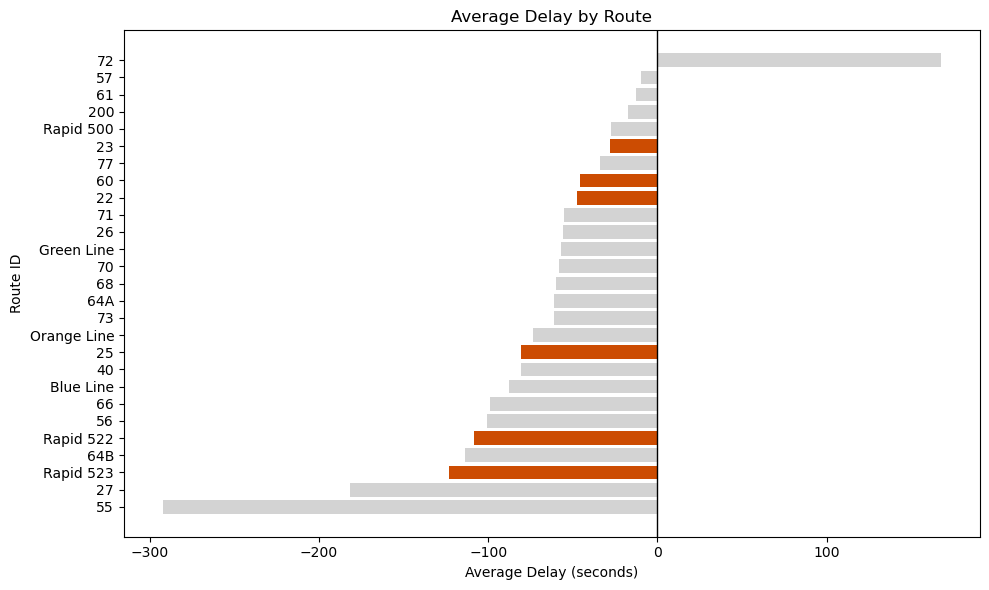

In [20]:
cleaned_data = pd.read_csv("../data/processed/cleaned_delay_data.csv")
route_delay = (
    cleaned_data.groupby("route_id_x")["computed_delay_sec"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("mean")
)

highlight_routes = ["22", "Rapid 522", "23", "Rapid 523", "25", "60"]

colors = [
    "#cc4c02" if route in highlight_routes else "#d3d3d3"
    for route in route_delay.index.astype(str)
]

plt.figure(figsize=(10, 6))
plt.barh(route_delay.index.astype(str), route_delay["mean"], color=colors)
plt.xlabel("Average Delay (seconds)")
plt.ylabel("Route ID")
plt.title("Average Delay by Route")
plt.axvline(0, color="black", linewidth=1)
plt.tight_layout()
plt.savefig("../visulizations/chart 01_average_delay_by_route.png", dpi=300)
plt.show()

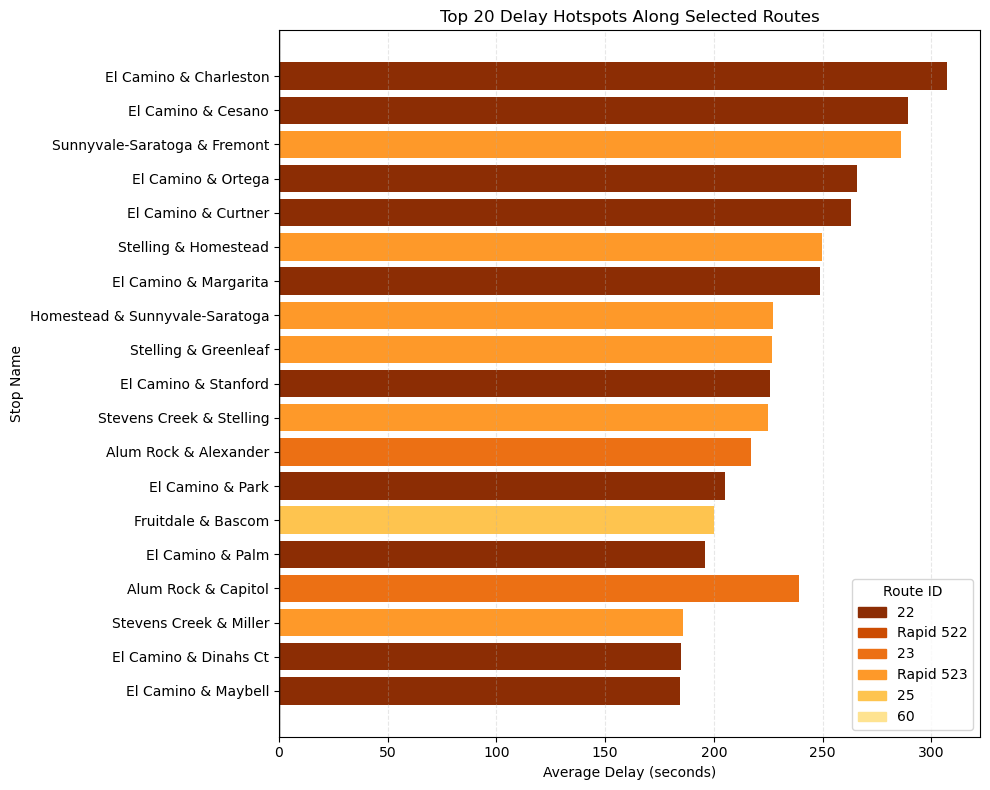

In [10]:
selected_routes = ["22", "Rapid 522", "23", "Rapid 523", "25", "60"]

filtered_data = cleaned_data[
    cleaned_data["route_id_x"].astype(str).isin(selected_routes)
]

stop_route_delay = (
    filtered_data.groupby(["route_id_x", "stop_name"])["computed_delay_sec"]
    .mean()
    .reset_index()
)

top20_stops = stop_route_delay.sort_values("computed_delay_sec", ascending=False).head(20)

route_colors = {
    "22": "#8c2d04",
    "Rapid 522": "#cc4c02",
    "23": "#ec7014",
    "Rapid 523": "#fe9929",
    "25": "#fec44f",
    "60": "#fee391"
}

top20_stops = top20_stops.sort_values("computed_delay_sec")
colors = top20_stops["route_id_x"].map(route_colors)

plt.figure(figsize=(10, 8))
plt.barh(top20_stops["stop_name"], top20_stops["computed_delay_sec"], color=colors)

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in route_colors.values()]
plt.legend(handles, route_colors.keys(), title="Route ID", loc="lower right")

plt.xlabel("Average Delay (seconds)")
plt.ylabel("Stop Name")
plt.title("Top 20 Delay Hotspots Along Selected Routes")
plt.axvline(0, color="black", linewidth=1)
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig("../visulizations/chart 02_top20_delay_hotspots.png", dpi=300)
plt.show()

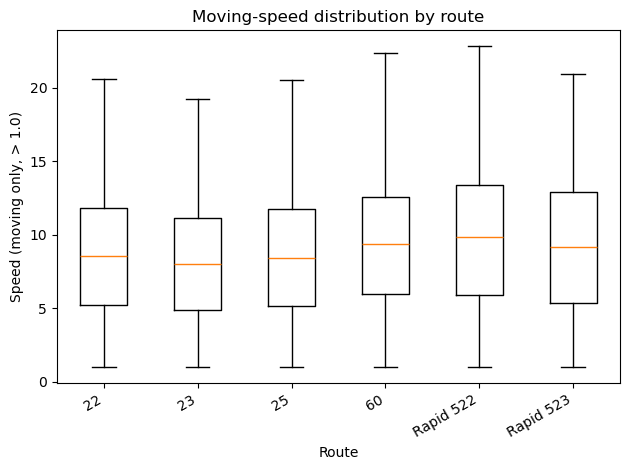

In [13]:
MOVING_TH = 1.0
df_move = df[df["speed"] > MOVING_TH].copy()

routes_order = sorted(df_move["route_id"].unique(), key=lambda x: (x.startswith("Rapid"), x))
data = [df_move.loc[df_move["route_id"] == r, "speed"].values for r in routes_order]

plt.figure()
plt.boxplot(data, tick_labels=routes_order, showfliers=False)
plt.xlabel("Route")
plt.ylabel(f"Speed (moving only, > {MOVING_TH})")
plt.title("Moving-speed distribution by route")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig("../visulizations/chart 03_Moving-speed_distribution_by_route.png", dpi=300)
plt.show()

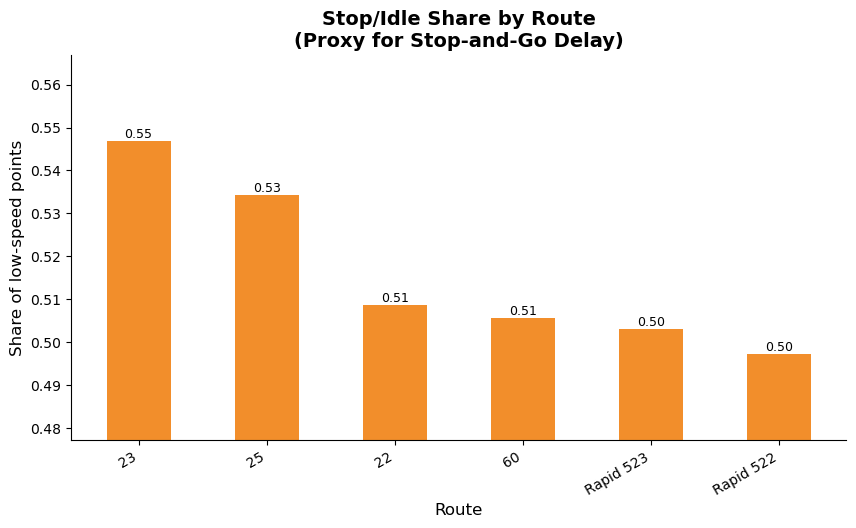

In [23]:
STOP_TH = 0.5

stop_share = (
    df.assign(is_stop=df["speed"] < STOP_TH)
      .groupby("route_id")["is_stop"]
      .mean()
      .reset_index()
      .rename(columns={"is_stop": "stop_share"})
      .sort_values("stop_share", ascending=False)
)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    stop_share["route_id"],
    stop_share["stop_share"],
    color="#F28E2B",  
    width=0.5        
)

plt.ylim(stop_share["stop_share"].min() - 0.02,
         stop_share["stop_share"].max() + 0.02)

plt.xlabel("Route", fontsize=12)
plt.ylabel("Share of low-speed points", fontsize=12)
plt.title("Stop/Idle Share by Route\n(Proxy for Stop-and-Go Delay)",
          fontsize=14, weight="bold")

plt.xticks(rotation=30, ha="right")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )


plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["left"].set_linewidth(0.8)
plt.gca().spines["bottom"].set_linewidth(0.8)

plt.savefig("../visulizations/chart 04_proxy_for_stop-and-go_delay.png", dpi=300)
plt.show()

Saved: ../03-output-graphics/map_grid_stopshare_1200ft.html


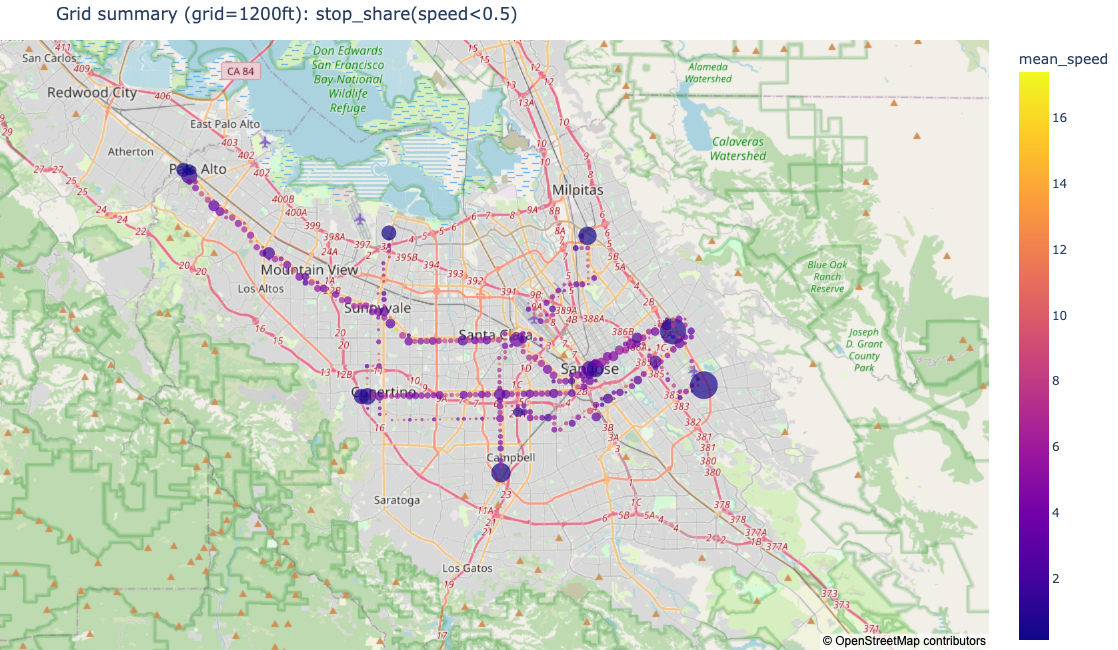

In [12]:
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["lon"], df["lat"]),
    crs="EPSG:4326"
).to_crs("EPSG:2227")

GRID_FT = 1200  
gdf["gx"] = (gdf.geometry.x // GRID_FT) * GRID_FT
gdf["gy"] = (gdf.geometry.y // GRID_FT) * GRID_FT

STOP_TH = 0.5
gdf["is_stop"] = gdf["speed"] < STOP_TH

grid = (
    gdf.groupby(["gx", "gy"])
       .agg(
           mean_speed=("speed", "mean"),
           stop_share=("is_stop", "mean"),
           n=("speed", "size"),
       )
       .reset_index()
)


grid = grid[grid["n"] >= 20].copy()

# back to lat/lon for mapping
grid_gdf = gpd.GeoDataFrame(
    grid,
    geometry=gpd.points_from_xy(grid["gx"], grid["gy"]),
    crs="EPSG:2227"
).to_crs("EPSG:4326")
grid_gdf["lat"] = grid_gdf.geometry.y
grid_gdf["lon"] = grid_gdf.geometry.x

import plotly.express as px
fig = px.scatter_map(
    grid_gdf,
    lat="lat",
    lon="lon",
    size="n",
    color="mean_speed",          
    hover_data=["mean_speed", "stop_share", "n"],
    zoom=10,
    height=650,
    title=f"Grid summary (grid={GRID_FT}ft): stop_share(speed<{STOP_TH})"
)
fig.update_layout(map_style="open-street-map", margin={"r":0,"t":40,"l":0,"b":0})

out_html = os.path.join(OUT_DIR, f"map_grid_stopshare_{GRID_FT}ft.html")
fig.write_html(out_html)
print("Saved:", out_html)
fig.show()